In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
file_path_1 = r"D:\Singapore\Alzheimer\R files\final data_new\imoutations_diff_ks\final_data_imputed_k1.csv"
df_real = pd.read_csv(file_path_1)
df_real

,RID,AGE,PTGENDER,PTEDUCAT,PTRACCAT,PTMARRY,APOE4,FDG,AV45,ABETA,...,Entorhinal,Fusiform,MidTemp,ICV,RAVLT.learning,RAVLT.forgetting,RAVLT.perc.forgetting,MOCA_bl,vascular,convert_Within_3Years
0,4,68,0,10,0,0,0,1.281469,0.9643,1501.0,...,3983,19036,19615,1679444.575,7,4,36.363636,23,1,0
1,5,74,0,16,0,0,0,1.259559,1.4170,547.3,...,4433,24788,21614,1640766.112,4,4,44.444444,26,1,0
2,6,80,1,13,0,0,0,1.123660,1.6112,761.5,...,2277,17963,17802,1485833.989,1,5,83.333333,20,1,0
3,8,84,1,18,0,0,0,1.209653,1.0237,1700.0,...,4190,14043,20076,1396068.139,7,3,25.000000,24,1,0
4,16,65,0,9,1,0,1,1.437162,1.1284,550.6,...,3470,15931,17596,1351996.795,8,6,50.000000,24,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,7000,90,1,16,0,0,0,1.315612,1.0361,1700.0,...,3360,18228,14136,1331036.482,1,4,100.000000,19,1,0
673,7010,59,0,18,0,0,1,1.309278,1.0981,1694.0,...,3755,20145,23471,1464664.639,8,3,20.000000,29,1,0
674,7012,57,1,16,1,1,1,1.484340,0.9960,637.8,...,4256,18922,23427,1371839.800,8,5,33.333333,23,1,0
675,7060,76,0,15,0,0,0,1.315612,1.0361,1700.0,...,3360,21027,22485,1612772.303,3,3,100.000000,20,1,0


In [3]:
file_path_2 = r"D:\Singapore\Alzheimer\R files\final data_new\synthetic_data\TVAE\group_1_3\synthetic_group_3_TVAE_3x.csv"
df_syn = pd.read_csv(file_path_2)

In [4]:
fig_save_dir = r"D:\Singapore\Alzheimer\R files\final data_new\figures\HIST"
os.makedirs(fig_save_dir, exist_ok=True)

In [5]:
numeric_cols = ['CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'RAVLT.immediate', 'RAVLT.learning', 'RAVLT.forgetting', 'RAVLT.perc.forgetting', 'LDELTOTAL', 'TRABSCOR', 'FAQ', 'EcogPtTotal', 'MOCA_bl', 'MMSE_bl',
            'FDG', 'AV45', 'ABETA', 'TAU', 'PTAU', 'PTEDUCAT', 'AGE']
categorical_cols = ['PTGENDER', 'PTRACCAT', 'PTMARRY']
numeric_cols.index("CDRSB")

0

In [6]:
title_cols = ['CDRSB', 'ADAS-11', 'ADAS-13', 'ADASQ-4', 'RAVLT.immediate', 'RAVLT.learning', 'RAVLT.forgetting', 'RAVLT % forgetting', 'LDEL Total', 'TRABSCOR', 'FAQ', 'EcogPtTotal', 'MoCA', 'MMSE',
            'FDG', 'AV45', 'ABETA', 'TAU', 'PTAU', 'PTEDUCAT', 'AGE']

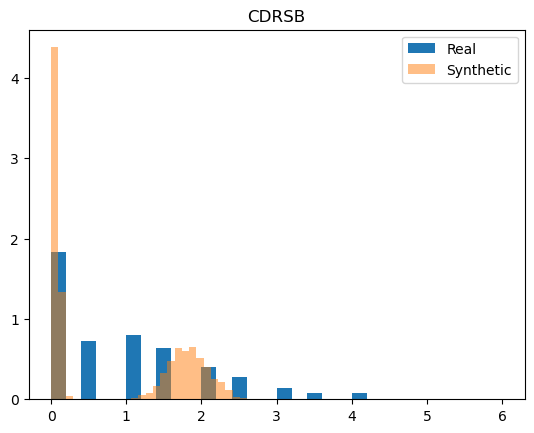

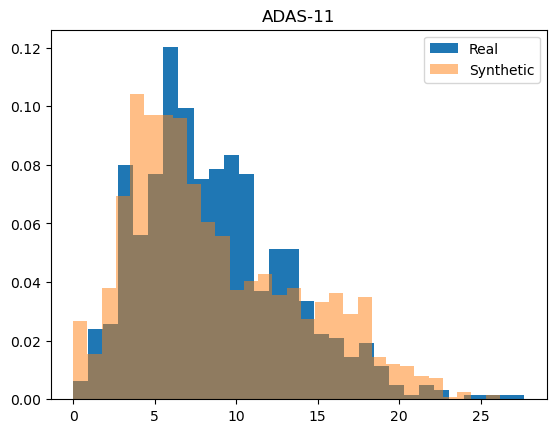

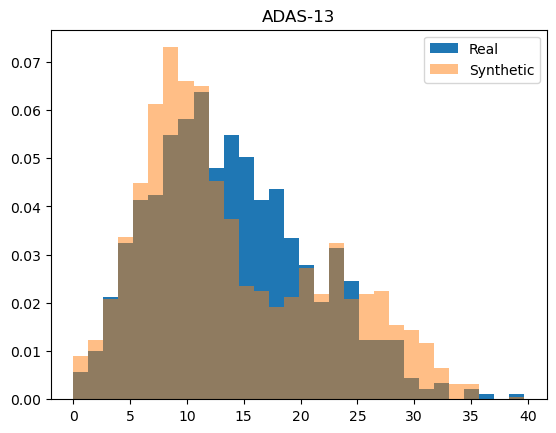

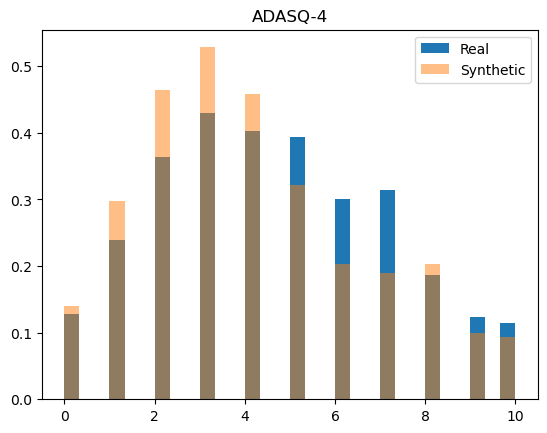

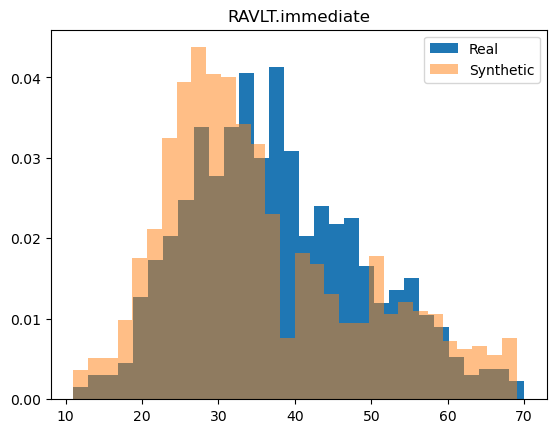

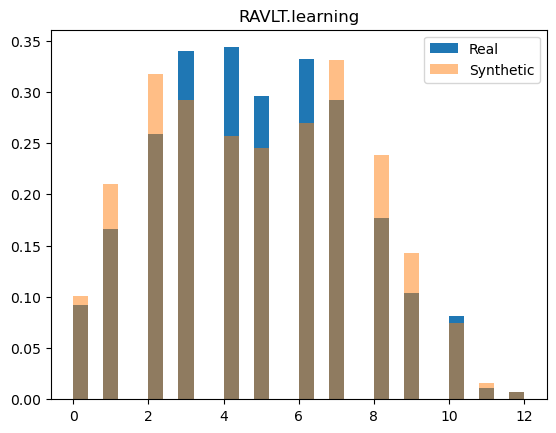

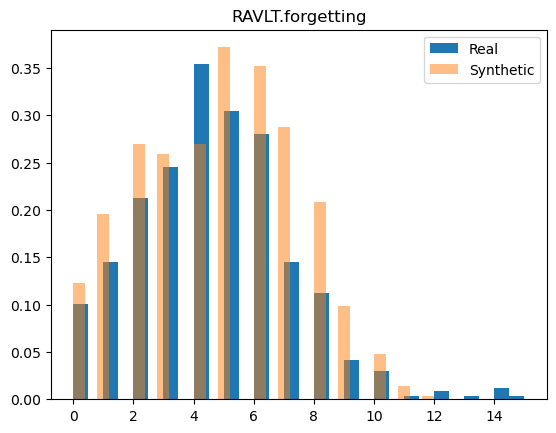

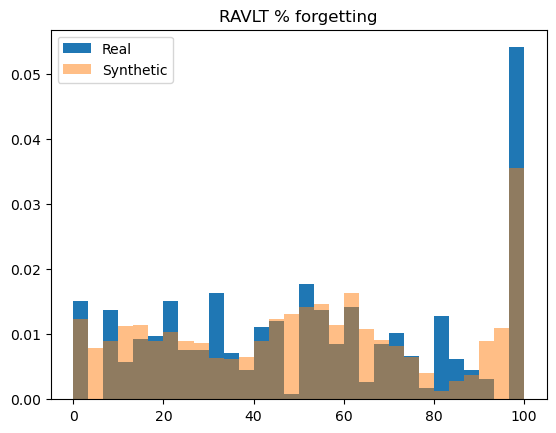

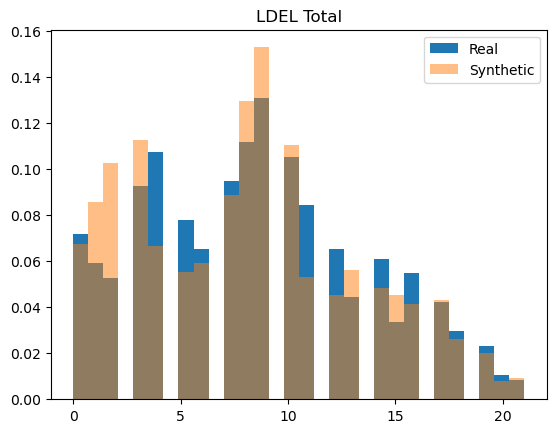

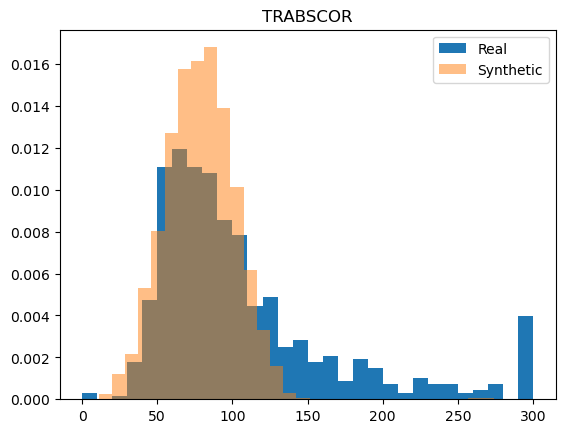

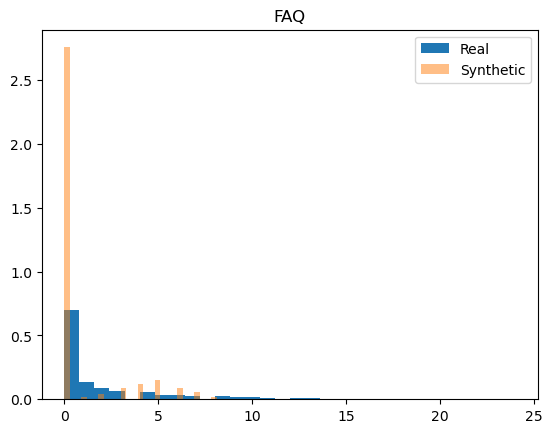

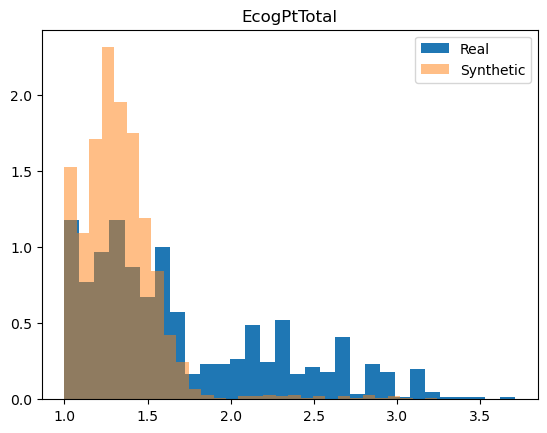

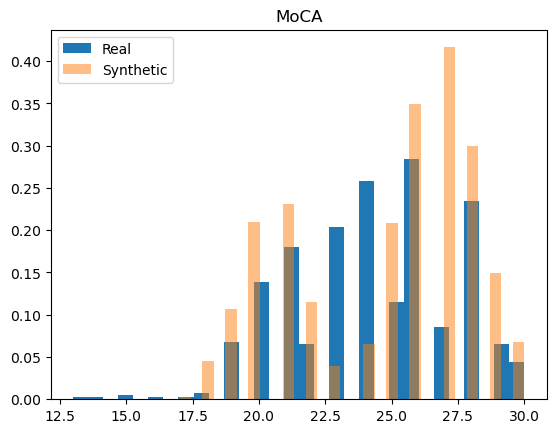

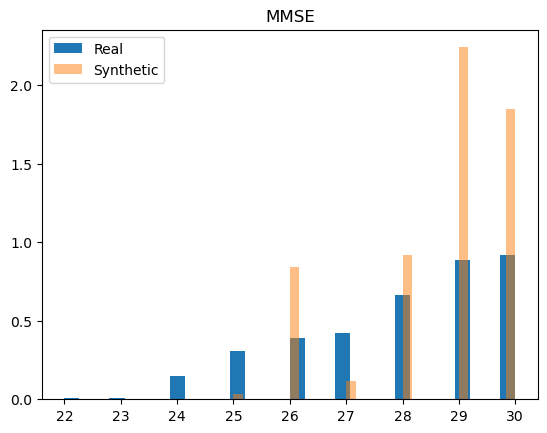

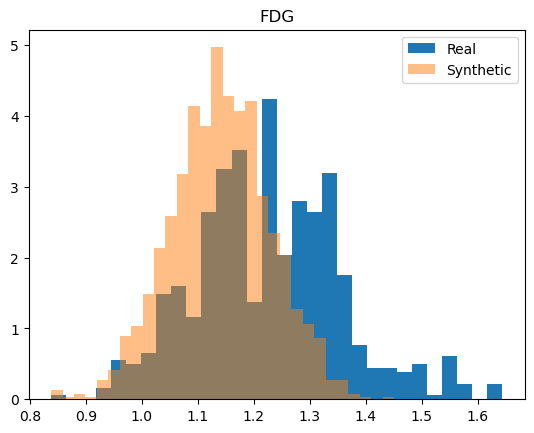

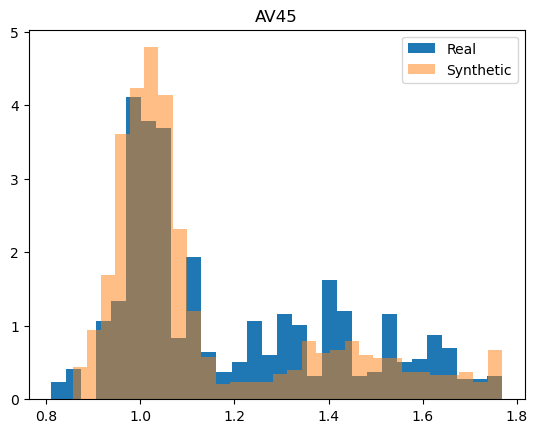

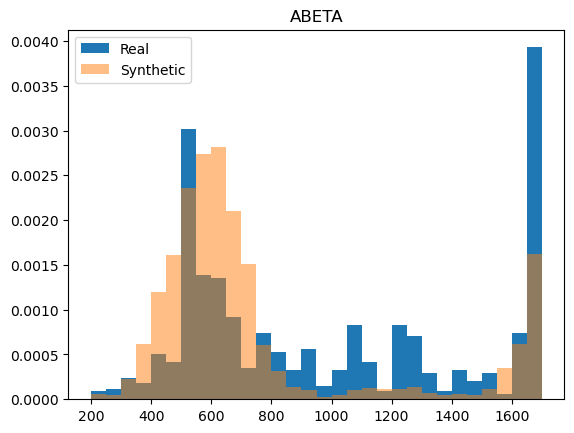

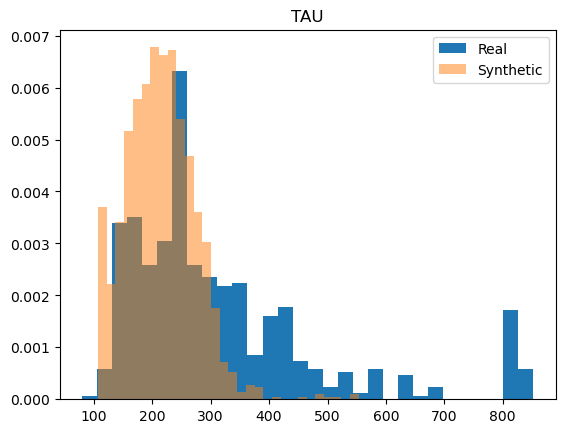

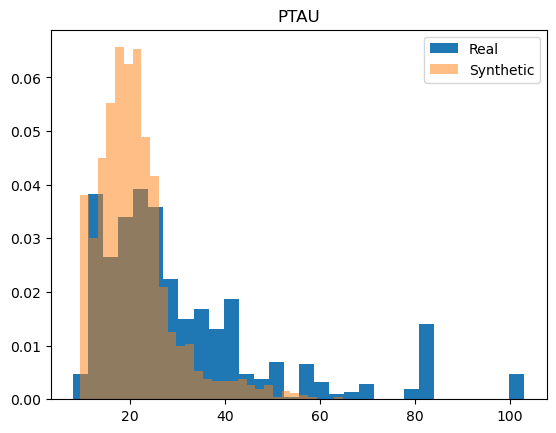

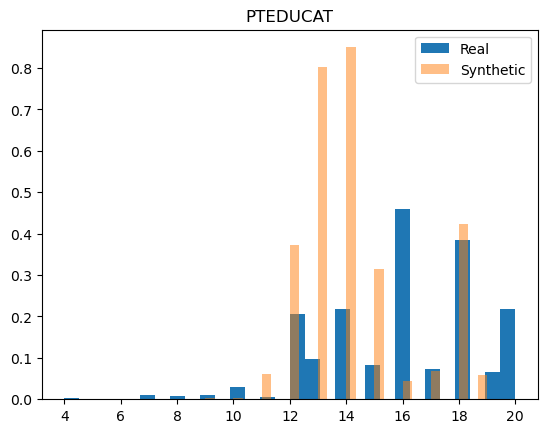

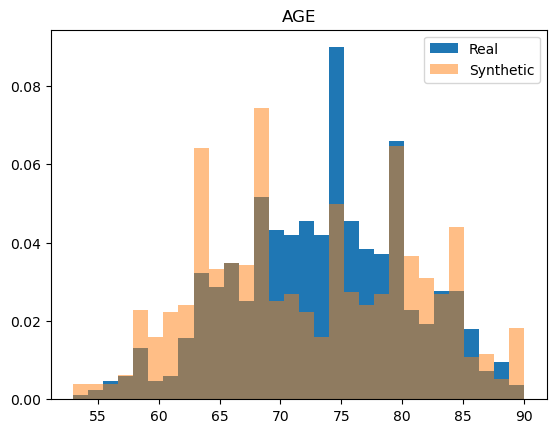

In [7]:
def plot_numeric(col):
    plt.figure()
    plt.hist(df_real[col], bins=30, alpha=1, label="Real", density=True)
    plt.hist(df_syn[col], bins=30, alpha=0.5, label="Synthetic", density=True)
    plt.title(title_cols[numeric_cols.index(col)])
    plt.legend()
    plt.savefig(os.path.join(fig_save_dir, f"Histogram_{c}.pdf"), dpi=600,bbox_inches="tight")
    plt.show()

for c in numeric_cols:
    plot_numeric(c)

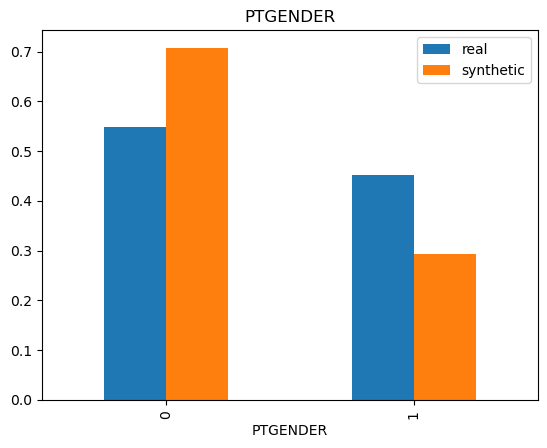

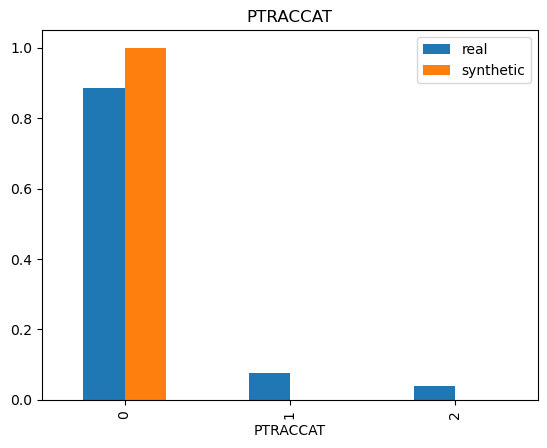

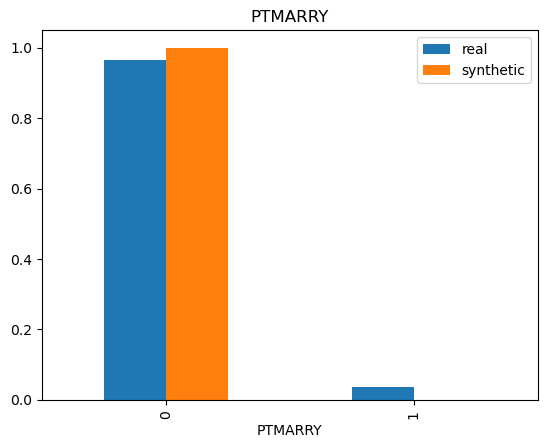

In [8]:
def plot_categorical(col):
    real_counts = df_real[col].value_counts(normalize=True)
    synth_counts = df_syn[col].value_counts(normalize=True)

    df = pd.DataFrame({
        "real": real_counts,
        "synthetic": synth_counts
    }).fillna(0)

    df.plot(kind="bar")
    plt.title(col)
    plt.savefig(os.path.join(fig_save_dir, f"Histogram_{c}.pdf"), dpi=600,bbox_inches="tight")
    plt.show()

for c in categorical_cols:
    plot_categorical(c)

In [11]:
from scipy.stats import ks_2samp, wasserstein_distance

def compare_numeric(df_real, df_syn, col):
    r = df_real[col].dropna()
    s = df_syn[col].dropna()

    ks_stat = ks_2samp(r, s)
    wass = wasserstein_distance(r, s)

    return {
        "feature": col,
        "ks_stat": round(ks_stat, 3),
    }

num_results = [compare_numeric(df_real, df_syn, c) for c in numeric_cols]

num_results = pd.DataFrame(num_results)
num_results

TypeError: type KstestResult doesn't define __round__ method